In [1]:
import lightgbm as lgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

In [2]:
#Claud Synthetic Dataset
# 30 days of hourly data
dates = pd.date_range(start="2026-09-01", periods=24 * 30, freq="h")
df = pd.DataFrame({"timestamp": dates})

# Calendar features
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

# Weather
np.random.seed(42)
df["temperature_c"] = 15 + 5 * np.sin(2 * np.pi * df["hour"] / 24) + np.random.normal(0, 1, len(df))
df["precipitation_mm"] = np.where(np.random.rand(len(df)) < 0.15, np.random.exponential(1.5, len(df)), 0.0)

# Events
df["is_event"] = np.where((df["is_weekend"] == 1) & (df["hour"].isin([18, 19, 20, 21])), 1, 0)
df["event_capacity"] = df["is_event"] * 15000

# Target
total_capacity = 500
weekday_pattern = np.maximum(0, np.sin(np.pi * (df["hour"] - 6) / 12)) * (1 - df["is_weekend"]) * 300
weekend_pattern = np.maximum(0, np.sin(np.pi * (df["hour"] - 10) / 10)) * df["is_weekend"] * 150
rain_impact = df["precipitation_mm"] * 15
event_impact = df["is_event"] * 180

raw_occupancy = 30 + weekday_pattern + weekend_pattern + rain_impact + event_impact + np.random.normal(0, 10, len(df))
df["occupancy_count"] = np.clip(raw_occupancy, 0, total_capacity).astype(int)

df.head()

,timestamp,hour,day_of_week,is_weekend,temperature_c,precipitation_mm,is_event,event_capacity,occupancy_count
0,2026-09-01 00:00:00,0,1,0,15.496714,0.000000,0,0,31
1,2026-09-01 01:00:00,1,1,0,16.155831,0.000000,0,0,19
2,2026-09-01 02:00:00,2,1,0,18.147689,0.000000,0,0,42
3,2026-09-01 03:00:00,3,1,0,20.058564,0.000000,0,0,21
4,2026-09-01 04:00:00,4,1,0,19.095974,0.055246,0,0,40


In [3]:
features = ["hour", "day_of_week", "is_weekend", "temperature_c",
            "precipitation_mm", "is_event", "event_capacity"]
target = "occupancy_count"

cutoff = df["timestamp"].quantile(0.8)
train = df[df["timestamp"] <= cutoff]
test  = df[df["timestamp"] >  cutoff]

xTrain, yTrain = train[features], train[target]
xTest,  yTest  = test[features],  test[target]

print(f"Train: {len(train)} rows, Test: {len(test)} rows")

trainData = lgb.Dataset(xTrain, label=yTrain)
testData  = lgb.Dataset(xTest, label=yTest, reference=trainData)

Train: 576 rows, Test: 144 rows


In [4]:
params = {
    "objective": "regression",
    "metric": "mae",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 15,      # smaller = simpler trees
    "min_data_in_leaf": 10,
    "verbose": -1,
}

In [5]:
model = lgb.train(
    params,
    trainData,
    valid_sets=[trainData, testData],
    valid_names=["train", "test"],
    num_boost_round=500,
    callbacks=[lgb.log_evaluation(10), lgb.early_stopping(30)],
)
print("Best number of trees:", model.best_iteration)

Training until validation scores don't improve for 30 rounds
[10]	train's l1: 60.6316	test's l1: 58.9927
[20]	train's l1: 37.5303	test's l1: 36.7088
[30]	train's l1: 23.9199	test's l1: 24.2583
[40]	train's l1: 16.1976	test's l1: 17.1925
[50]	train's l1: 11.7356	test's l1: 13.0576
[60]	train's l1: 9.83035	test's l1: 11.2826
[70]	train's l1: 9.00421	test's l1: 10.4901
[80]	train's l1: 8.4774	test's l1: 10.164
[90]	train's l1: 8.11179	test's l1: 10.0467
[100]	train's l1: 7.827	test's l1: 9.89267
[110]	train's l1: 7.62653	test's l1: 9.81156
[120]	train's l1: 7.4801	test's l1: 9.79484
[130]	train's l1: 7.33082	test's l1: 9.75867
[140]	train's l1: 7.19975	test's l1: 9.76707
[150]	train's l1: 7.0997	test's l1: 9.7835
Early stopping, best iteration is:
[128]	train's l1: 7.35971	test's l1: 9.75596
Best number of trees: 128


In [6]:
yPred = model.predict(xTest, num_iteration=model.best_iteration)
yPred = np.clip(yPred, 0, total_capacity)

mae = mean_absolute_error(yTest, yPred)
baseline_mae = mean_absolute_error(yTest, np.full(len(yTest), yTrain.mean()))

print(f"Model MAE:    {mae:.1f} spots")
print(f"Baseline MAE: {baseline_mae:.1f} spots")

Model MAE:    9.8 spots
Baseline MAE: 96.8 spots


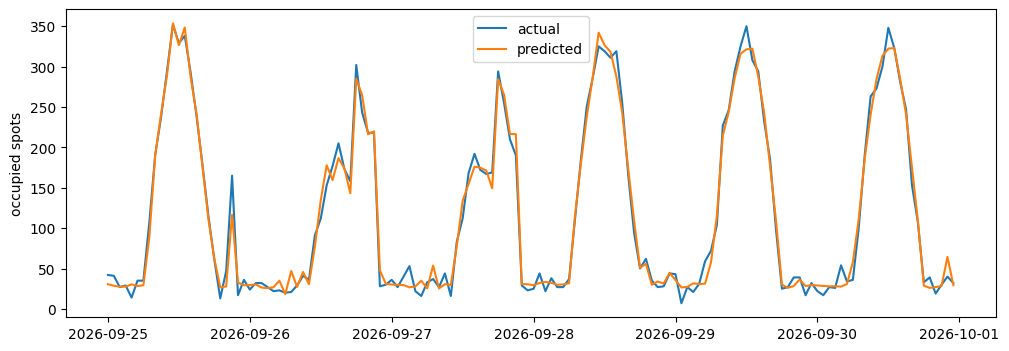

In [7]:
plt.figure(figsize=(12, 4))
plt.plot(test["timestamp"], yTest.values, label="actual")
plt.plot(test["timestamp"], yPred, label="predicted")
plt.ylabel("occupied spots")
plt.legend()
plt.show()

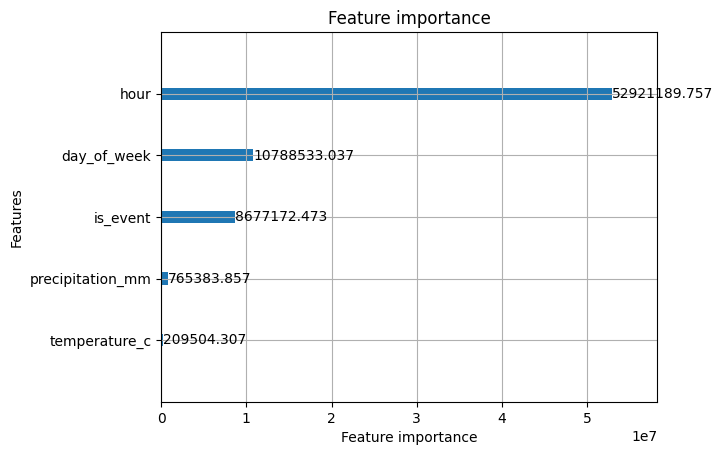

In [8]:
lgb.plot_importance(model, importance_type="gain", max_num_features=10)
plt.show()

In [9]:
model.save_model("parking_model.txt")